# ETF costs: where the edge runs out

Every Sharpe ratio so far was earned at one cost level - the one `config/setup.yaml` declares.
That single number hides the question a reader actually needs answered, which is not "what did it
make" but **"how much friction would it take to make nothing"**. A strategy whose Sharpe is
unchanged at four times the declared cost is a different proposition from one that breaks even
just above it, even when the two report the same number today.

This notebook walks a cost grid over the leading allocation-stage combinations and registers a
backtest at each level, so the decay curve is a set of registered results rather than an
extrapolation from one point.

**Two cost regimes are swept, and they are not two views of one thing.** The case study's
declared model is per-share commission plus a half-spread in cents, which is how an ETF actually
trades: the cost of a share does not scale with its price. The basis-point grid is the convention
most of the literature uses and most other case studies here declare, and it is run alongside as
a comparator. The two disagree by construction - a one-cent half-spread is about one basis point
on a $500 fund and about five on a $20 one - so the panels are read for their slopes and their
breakevens, not point against point.

**Learning objectives**

- Read a cost decay curve and locate the level at which a strategy stops paying.
- Say why a per-share cost model and a basis-point cost model give different answers on the same
  universe, and which one this universe is priced under.
- Say what a uniform cost sweep does and does not tell you about a strategy priced under a
  per-asset spread map.

**Book reference**: Chapter 18, Sections 18.2 to 18.5.

**Prerequisites**: [`16_risk_management`](16_risk_management.ipynb), and through it
[`15_portfolio_management`](15_portfolio_management.ipynb) and [`14_backtest`](14_backtest.ipynb).
This is the last stage that selects, so it runs after all three and draws from all of them.

**What it writes**: one row in `backtest_runs` per combination and cost level, at
`stage='cost_sensitivity'`, under both regimes.

In [1]:
"""Re-price the leading ETF allocation combinations across two cost-model grids."""

import json
import sqlite3
import time
import warnings

import plotly.graph_objects as go
import polars as pl
import yaml
from plotly.subplots import make_subplots

from case_studies.research import open_study, split_unpublished_members
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import STAGE_SEQUENCE
from utils.paths import get_case_study_dir
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
LABEL = ""
MAX_SYMBOLS = 0
# None defers to the case study's configured count; an int caps it.
TOP_N_COMBOS = None
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical
# branch regenerates in place, which needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

## 1. What is being re-priced, and under what

The combinations are the highest-Sharpe validation runs across every stage a carrier can come
from - the equal-weight baseline, the allocation sweep and the risk overlay - not the allocation
stage alone. Each later stage is an alternative to the one before it rather than an improvement
on it by construction: where every allocator lands below the equal-weight parent it was built
from, an allocation-only rule would carry forward a strategy the earlier notebook measured as
worse than doing nothing, and where every risk control hurts, an overlay-only rule would charge
costs against an overlay the sweep just found unhelpful. Which stage wins is decided by
measurement here and printed below, not by which stages this query happens to name.

They are re-priced rather than re-selected: the prediction, the concentration and the allocator
are held exactly as registered, and the only thing that moves is the cost model. That is what
makes the curve below a statement about cost sensitivity and not about which strategy happens to
do best under friction.

The per-share commission is read from `setup.yaml` with no default. Elsewhere in the fleet that
key is exploratory and a missing value can fall back; here it is the headline regime, so a
missing key has to fail loudly rather than quietly re-price the whole sweep at somebody's
default.

In [3]:
# Configuration only. Anything that reads the registry resolves the directory at call time,
# because `Study.activate()` moves the output root for a preview run and this binding predates it.
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
if not LABEL:
    LABEL = bt_config.primary_label

COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)
COST_GRID_HALF_SPREAD_USD = get_cost_grid_half_spread_usd(CASE_STUDY_ID)
PER_SHARE_COMMISSION = float(
    yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())["costs"]["per_share"]
)

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")
print(f"Per-share commission: ${PER_SHARE_COMMISSION}/share")
print(f"Basis-point grid:     {COST_GRID_BPS}")
print(f"Half-spread grid (¢): {[round(v * 100, 2) for v in COST_GRID_HALF_SPREAD_USD]}")

Case study: etfs, label: fwd_ret_21d
Per-share commission: $0.0035/share
Basis-point grid:     [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0]
Half-spread grid (¢): [0.0, 0.5, 1.0, 2.5, 5.0, 10.0]


**The population the leaders are drawn from.** A refit publishes a second generation under the
same population name and leaves the one it replaced in the registry, backtests and all. Reading
the leaders without asking the population lineage lets a retired identity - or one no population
ever listed - be re-priced here and carried onward as though it were what the model notebook
publishes.

In [4]:
LIVE_PREDICTIONS = (
    split_unpublished_members(
        open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None),
        load_prediction_index(CASE_STUDY_ID, label=LABEL, split="validation"),
    )
    .live["prediction_hash"]
    .to_list()
)
if not LIVE_PREDICTIONS:
    raise RuntimeError(
        f"no live prediction sets for {CASE_STUDY_ID}/{LABEL}/validation; run 14_backtest first"
    )
print(f"Live prediction sets: {len(LIVE_PREDICTIONS):,}")

Live prediction sets: 277


In [5]:
# The stages the sweep may draw its carrier from. This is not a free choice: it is exactly the set
# `resolve_canonical_rank1_lineage` selects over,
# and the two have to agree. Pool anything narrower and they can name different configurations -
# the curve below would then describe a strategy `20_strategy_analysis` does not report, and that
# notebook would find no cost rows for the carrier it did select.
#
# Breadth is also what keeps the risk question empirical. The risk stage files one row per named
# control and none for the un-overlaid strategy, so a pool of `risk_overlay` alone would force an
# overlay onto the carrier even where every control hurt it - letting the shape of a query decide
# what the sweep is supposed to measure. `signal` and `allocation` are how an un-overlaid
# configuration wins when it deserves to.
#
# `cost_sensitivity` stays out: pooling it would let a cost-charged run re-enter the selection it
# is a consequence of. It is also the terminal stage, which is why taking everything before it
# is the whole pool rather than a subset of one - `STAGE_SEQUENCE` is the order the backtests
# run and `STAGE_CARRIER_BLOCK` records that nothing is ever built on top of a cost sweep.
# Derived from that sequence rather than written out again, so a stage added to the pipeline
# joins this pool without anyone remembering to come here.
#
# `holdout` is the one member of the resolver's list absent from both, and not by choice. That
# resolver reads `backtest_runs` with raw SQL; this path goes through
# `registry.store._stage_filter_clause`, whose `VALID_STAGES` raises on anything outside
# {signal, allocation, risk_overlay, cost_sensitivity}. Naming it here would not widen the pool,
# it would raise before the first stage was read. The two selections still agree, because the
# resolver asks for validation-split rows and a holdout-stage backtest is not one.
PRE_COST_STAGES = tuple(stage for stage in STAGE_SEQUENCE if stage != "cost_sensitivity")


def resolve_pre_cost_runs(top_n: int) -> pl.DataFrame:
    """The highest-Sharpe validation runs across every stage the carrier may come from.

    Each stage is asked for its whole ranked list and the pool is sorted afterwards, rather than
    taking `top_n` from each and merging them: truncating first lets one stage's leader hold a
    slot that a better run in another stage should have had, and at `top_n=1` that drops a whole
    stage from consideration instead of falling through to the next candidate.

    No solvency filter, unlike `us_firm_characteristics/14_costs`, which drops runs whose equity
    reached zero before sweeping them - its long-short book has no margin call, so a run can
    compound through zero and carry a Sharpe computed on a balance that no longer exists. That
    boundary belongs with the stages that apply it, and this case study's backtest stages apply
    none. Measured on this registry 2026-08-30: 1,289 backtests, none with `max_drawdown` at or
    past -100% and none missing it, so the filter would exclude nothing here while introducing a
    criterion the stages it draws from never used.
    """
    ranked = [
        frame.with_columns(pl.lit(stage).alias("pool_stage"))
        for stage, frame in (
            (
                stage,
                resolve_best_backtest_runs(
                    CASE_STUDY_ID,
                    LABEL,
                    split="validation",
                    stage=stage,
                    top_n=1_000_000,
                    prediction_hashes=set(LIVE_PREDICTIONS),
                ),
            )
            for stage in PRE_COST_STAGES
        )
        if not frame.is_empty()
    ]
    if not ranked:
        return pl.DataFrame()
    return (
        pl.concat(ranked)
        .sort("sharpe", descending=True)
        .unique("backtest_hash", maintain_order=True)
        .head(top_n)
    )

In [6]:
top_combos = resolve_pre_cost_runs(TOP_N_COMBOS)
if top_combos.is_empty():
    raise RuntimeError(
        "no backtests are registered at any of "
        f"{', '.join(PRE_COST_STAGES)}, so there is nothing to re-price; run 14_backtest, "
        "15_portfolio_management and 16_risk_management first"
    )
# `resolve_best_backtest_runs` returns the stored specification and the Sharpe, and nothing
# about the model behind it - the family and configuration are projected away. The model is
# read from the explorer and joined on `backtest_hash`, which both carry.
sources: dict[str, str] = {}
for _stage in PRE_COST_STAGES:
    sources.update(
        BacktestExplorer(CASE_STUDY_ID)
        .best(stage=_stage, top_n=100000, label=LABEL, prediction_hashes=LIVE_PREDICTIONS)
        .select("backtest_hash", "source")
        .iter_rows()
    )
# The stage each selected run came from is printed rather than assumed, because which one wins is
# the question the pool exists to leave open.
for row in top_combos.iter_rows(named=True):
    allocator = strategy_view(json.loads(row["spec_json"])).get("allocation", {}).get("method")
    print(
        f"  Sharpe={row['sharpe']:+.3f}  stage={row['pool_stage']}  "
        f"{sources.get(row['backtest_hash'], 'unknown source')}  "
        f"alloc={allocator}  backtest={row['backtest_hash'][:8]}"
    )

# Whether the overlay earned its place, reported rather than assumed. The risk stage files a row
# per named control and none for the un-overlaid strategy, so the two sides have to be read
# separately and differenced. A negative difference is the stage saying its controls did not help,
# which is a result and not a failure.
#
# Both sides are restricted to the same live population the carrier was selected from. Without
# that, a retired or unpublished generation can supply either Sharpe, and the difference would
# then compare a number the sweep would never carry against one it might.
_best: dict[str, float | None] = {}
for _stage in ("risk_overlay", "allocation"):
    _frame = resolve_best_backtest_runs(
        CASE_STUDY_ID,
        LABEL,
        split="validation",
        stage=_stage,
        top_n=1,
        prediction_hashes=set(LIVE_PREDICTIONS),
    )
    _best[_stage] = None if _frame.is_empty() else _frame["sharpe"][0]
if _best["risk_overlay"] is None:
    print("  Risk overlay: no run registered, so the carrier above is un-overlaid.")
elif _best["allocation"] is None:
    print(f"  Risk overlay: {_best['risk_overlay']:+.3f}, with no allocation run to compare it to.")
else:
    _delta = _best["risk_overlay"] - _best["allocation"]
    print(
        f"  Best overlaid {_best['risk_overlay']:+.3f} vs best un-overlaid "
        f"{_best['allocation']:+.3f}, difference {_delta:+.3f}"
    )

  Sharpe=+1.150  stage=risk_overlay  gbm/default_mae  alloc=inverse_vol  backtest=fb287093
  Best overlaid +1.150 vs best un-overlaid +0.839, difference +0.311


In [7]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} tradeable funds")

Prices: 198,877 rows, 100 tradeable funds


## 2. Sweeping both grids

**The sweep applies one flat rate to every fund, which the production backtests do not.** The
signal, allocation and risk stages price each fund from the tiered per-asset half-spread map in
`setup.yaml` - a half cent on the largest funds, a cent on the sector funds, two cents by
default. What follows is therefore one-axis sensitivity to a universe-wide cost level, not a
re-pricing of the live cost structure. Read the slope and the crossing point; do not read a
single point as what the strategy would have earned.

In [8]:
# Accumulated across both regime sweeps and read by the curve loader below.
SWEPT_COST_HASHES: set[str] = set()


def _stage_of(backtest_hash: str) -> str | None:
    """The stage one backtest was actually registered under, read back from the registry.

    The directory is resolved here rather than reused from `CASE_DIR`, which is bound above
    the first `open_study` call. `Study.activate()` re-points the output root at
    `<workspace>/.preview` for a preview run, so a preview sweep registers into a registry
    that `CASE_DIR` does not name - and this check would then read the canonical database,
    find none of the hashes it just wrote, and report every one of them misfiled. Resolving
    at call time is what `resolve_best_backtest_runs` and `load_existing_backtest_hashes`
    already do, so this reads the same database the rest of the notebook does.
    """
    registry = get_case_study_dir(CASE_STUDY_ID) / "run_log" / "registry.db"
    with sqlite3.connect(str(registry)) as conn:
        row = conn.execute(
            "SELECT stage FROM backtest_runs WHERE backtest_hash = ?", (backtest_hash,)
        ).fetchone()
    return None if row is None else row[0]


def sweep_costs(regime: str, grid, apply_costs) -> tuple[int, list[dict]]:
    """Re-price every leading combination at every level of one cost grid.

    Prints two facts a reader needs both of: what the stage held before this run, and what this
    execution did. `run_backtest` returns a cached result and a fresh fit through the same call,
    so a warm re-run would otherwise report a completed sweep in no time at all - a wrong number
    that looks exactly like a right one - while reporting only what this run computed would make
    that same re-run look like an empty stage.

    Failures carry the exception that caused them. A count on its own cannot distinguish a sweep
    that lost one level from one that lost every level of a regime, and the two mean very
    different things about the curve.
    """
    registered, served, failures = 0, 0, []
    started = time.time()
    total = len(top_combos) * len(grid)
    # Every row this sweep stands behind, cached ones included. The registry also holds
    # cost-sensitivity rows from earlier sweeps whose leaders differed; averaging those into the
    # curves below would price a combination this run never selected.
    swept: set[str] = SWEPT_COST_HASHES
    registered_before = load_existing_backtest_hashes(CASE_STUDY_ID, stage="cost_sensitivity")
    print(f"{regime}: {len(registered_before):,} cost-sensitivity backtests already registered")

    for combo_row in top_combos.iter_rows(named=True):
        pred_hash = combo_row["prediction_hash"]
        base_spec = ensure_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            json.loads(combo_row["spec_json"]),
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
        )
        allocator = strategy_view(base_spec).get("allocation", {}).get("method", "equal_weight")
        predictions = read_predictions(CASE_STUDY_ID, pred_hash)

        for level in grid:
            spec = apply_costs(clone_backtest_spec(base_spec), level)
            spec["chapter"] = "ch18"
            try:
                result = run_backtest(
                    CASE_STUDY_ID,
                    pred_hash,
                    spec,
                    prices=prices,
                    predictions=predictions,
                    label=LABEL,
                    register=True,
                    initial_cash=bt_config.initial_cash,
                    calendar=bt_config.calendar,
                )
            except Exception as error:
                failures.append(
                    {
                        "regime": regime,
                        "allocator": allocator,
                        "level": level,
                        "error": f"{type(error).__name__}: {error}",
                    }
                )
                continue
            swept.add(result.backtest_hash)
            if result.backtest_hash in registered_before:
                served += 1
            registered += 1
            print(
                f"  [{registered}/{total}] {regime} {allocator} @ {level}: "
                f"Sharpe={result.metrics.get('sharpe', 0):+.3f}"
            )

    print(
        f"{regime} sweep in {time.time() - started:.0f}s: {registered - served} computed, "
        f"{served} served from the registry, {len(failures)} failed"
    )
    return registered, failures


bps_done, bps_failures = sweep_costs(
    "bps",
    COST_GRID_BPS,
    lambda spec, level: set_backtest_costs_bps(
        spec, commission_bps=level / 2, slippage_bps=level / 2
    ),
)
ps_done, ps_failures = sweep_costs(
    "per-share",
    COST_GRID_HALF_SPREAD_USD,
    lambda spec, level: set_backtest_costs_per_share(
        spec, per_share=PER_SHARE_COMMISSION, default_half_spread_usd=level
    ),
)

bps: 68 cost-sensitivity backtests already registered
  SKIP backtest (complete (hash=b8aa1cdd7daa)) — reusing cached result
  [1/11] bps inverse_vol @ 0.0: Sharpe=+1.223
  SKIP backtest (complete (hash=19b6640070fb)) — reusing cached result
  [2/11] bps inverse_vol @ 1.0: Sharpe=+1.209
  SKIP backtest (complete (hash=1a062e3a228a)) — reusing cached result
  [3/11] bps inverse_vol @ 2.0: Sharpe=+1.195
  SKIP backtest (complete (hash=e78bb1d3b525)) — reusing cached result
  [4/11] bps inverse_vol @ 3.0: Sharpe=+1.181
  SKIP backtest (complete (hash=4a21adeeeb0c)) — reusing cached result
  [5/11] bps inverse_vol @ 5.0: Sharpe=+1.151
  SKIP backtest (complete (hash=0b5306bd040f)) — reusing cached result
  [6/11] bps inverse_vol @ 7.0: Sharpe=+1.122


  SKIP backtest (complete (hash=087d0b354e02)) — reusing cached result
  [7/11] bps inverse_vol @ 10.0: Sharpe=+1.078


  SKIP backtest (complete (hash=280b82d6e3cb)) — reusing cached result
  [8/11] bps inverse_vol @ 15.0: Sharpe=+1.004
  SKIP backtest (complete (hash=4cdc24739b5d)) — reusing cached result
  [9/11] bps inverse_vol @ 20.0: Sharpe=+0.930
  SKIP backtest (complete (hash=e0a69d076d4c)) — reusing cached result
  [10/11] bps inverse_vol @ 30.0: Sharpe=+0.782
  SKIP backtest (complete (hash=38e80abeb593)) — reusing cached result
  [11/11] bps inverse_vol @ 50.0: Sharpe=+0.488
bps sweep in 0s: 0 computed, 11 served from the registry, 0 failed
per-share: 68 cost-sensitivity backtests already registered
  SKIP backtest (complete (hash=4550ed506ac3)) — reusing cached result
  [1/6] per-share inverse_vol @ 0.0: Sharpe=+1.212
  SKIP backtest (complete (hash=dfc484bbd884)) — reusing cached result
  [2/6] per-share inverse_vol @ 0.005: Sharpe=+1.196
  SKIP backtest (complete (hash=64dbf3879c25)) — reusing cached result
  [3/6] per-share inverse_vol @ 0.01: Sharpe=+1.179


  SKIP backtest (complete (hash=fc74f461a553)) — reusing cached result


  [4/6] per-share inverse_vol @ 0.025: Sharpe=+1.127
  SKIP backtest (complete (hash=9a4fb11a0da8)) — reusing cached result
  [5/6] per-share inverse_vol @ 0.05: Sharpe=+1.042
  SKIP backtest (complete (hash=ca3542c6eaf9)) — reusing cached result
  [6/6] per-share inverse_vol @ 0.1: Sharpe=+0.872
per-share sweep in 0s: 0 computed, 6 served from the registry, 0 failed


In [9]:
# Every hash this sweep registered has to have landed at `cost_sensitivity`. It is checked rather
# than assumed because the stage is inferred from the spec, and the spec being priced is a clone of
# the carrier's - so a carrier from the risk stage brings its risk block along, and an inference
# that read that block before the chapter tag would file the whole curve as new risk overlays. The
# readback below would then report an empty stage, which points at the sweep rather than at the
# classification. This names it.
_misfiled = {
    _hash: _stage
    for _hash, _stage in ((_hash, _stage_of(_hash)) for _hash in sorted(SWEPT_COST_HASHES))
    if _stage != "cost_sensitivity"
}
if _misfiled:
    raise RuntimeError(
        f"{len(_misfiled)} of {len(SWEPT_COST_HASHES)} cost-sweep backtests were registered "
        f"under the wrong stage, e.g. {sorted(_misfiled.items())[:3]}; they carry chapter='ch18' "
        "so `registry.store._infer_stage` should classify them as cost_sensitivity"
    )

In [10]:
failures = bps_failures + ps_failures
if failures:
    failure_frame = pl.DataFrame(failures)
    print(f"{failure_frame.height} backtests raised. Distinct causes:")
    print(failure_frame.group_by("regime", "error").len().sort("len", descending=True))
else:
    print("no backtest raised in either regime")

no backtest raised in either regime


## 3. The decay curves

Read back from the registry rather than from the sweep, so a resumed run and a fresh one show the
same thing. Each row's cost level and allocator come out of its own registered specification,
which is what the backtest hash was taken over.

In [11]:
COST_REGIMES = {"percentage": "bps per leg", "per_share": "cents of half-spread per share"}


def load_cost_curve(commission_model: str) -> pl.DataFrame:
    """Read the registered cost-sensitivity rows for one commission model."""
    rows = resolve_best_backtest_runs(
        CASE_STUDY_ID,
        LABEL,
        split="validation",
        stage="cost_sensitivity",
        top_n=100000,
        prediction_hashes=set(LIVE_PREDICTIONS),
    )
    if rows.is_empty():
        return pl.DataFrame()
    # Not every cost-sensitivity row for a live prediction belongs to this sweep: a previous
    # leader that is still live left its own curve behind. Keep the rows this run produced.
    rows = rows.filter(pl.col("backtest_hash").is_in(list(SWEPT_COST_HASHES)))
    if rows.is_empty():
        return pl.DataFrame()
    parsed = []
    for row in rows.iter_rows(named=True):
        spec = json.loads(row["spec_json"])
        config = spec.get("backtest_config", {})
        commission, slippage = config.get("commission", {}), config.get("slippage", {})
        if commission.get("model") != commission_model:
            continue
        level = (
            round((commission.get("rate", 0.0) + slippage.get("rate", 0.0)) * 10_000.0, 4)
            if commission_model == "percentage"
            else round(slippage.get("spread", 0.0) * 100.0, 4)
        )
        parsed.append(
            {
                "level": level,
                "sharpe": row["sharpe"],
                "allocator": strategy_view(spec)
                .get("allocation", {})
                .get("method", "equal_weight"),
            }
        )
    if not parsed:
        return pl.DataFrame()
    return (
        pl.DataFrame(parsed)
        .group_by("allocator", "level")
        .agg(pl.col("sharpe").mean())
        .sort("allocator", "level")
    )


bps_curve = load_cost_curve("percentage")
ps_curve = load_cost_curve("per_share")
if bps_curve.is_empty() and ps_curve.is_empty():
    raise RuntimeError("the cost-sensitivity stage registered no readable rows")
print(f"basis-point regime: {bps_curve.height} allocator-level points")
print(f"per-share regime:   {ps_curve.height} allocator-level points")

basis-point regime: 11 allocator-level points
per-share regime:   6 allocator-level points


### Where each regime crosses zero

The breakeven is the cost level at which the mean Sharpe crosses zero, interpolated between the
two grid points that bracket it. A curve that never crosses within the grid has no breakeven to
report, and saying so is the answer: the grid did not reach far enough to find one.

In [12]:
def breakeven(curve: pl.DataFrame) -> tuple[str, float | None]:
    """Where the mean Sharpe first crosses zero, and which of three cases the curve is.

    Returns one of "crosses" with the interpolated level, "never_positive" when the curve is
    already at or below zero at the cheapest level on the grid, or "stays_positive" when it
    has not crossed by the most expensive. The three are different findings and collapsing
    them into "no breakeven" would report a strategy that never paid and one that always paid
    with the same sentence.
    """
    if curve.is_empty():
        return "empty", None
    mean_curve = curve.group_by("level").agg(pl.col("sharpe").mean()).sort("level")
    levels = mean_curve["level"].to_list()
    sharpes = mean_curve["sharpe"].to_list()
    if sharpes[0] <= 0:
        return "never_positive", levels[0]
    for (low, low_sharpe), (high, high_sharpe) in zip(
        zip(levels, sharpes, strict=True), zip(levels[1:], sharpes[1:], strict=True), strict=False
    ):
        if low_sharpe >= 0 > high_sharpe:
            return "crosses", low + (high - low) * low_sharpe / (low_sharpe - high_sharpe)
    return "stays_positive", levels[-1]


for name, curve, unit in [
    ("basis points per leg", bps_curve, "bps"),
    ("cents of half-spread", ps_curve, "¢"),
]:
    case, level = breakeven(curve)
    if case == "empty":
        print(f"{name}: no registered rows")
    elif case == "never_positive":
        print(
            f"{name}: mean Sharpe is already at or below zero at {level}{unit}, the cheapest "
            "level on the grid, so there is no edge for cost to consume"
        )
    elif case == "stays_positive":
        print(
            f"{name}: mean Sharpe is still above zero at {level}{unit}, the most expensive "
            "level on the grid, so the grid does not reach the breakeven"
        )
    else:
        print(f"{name}: mean Sharpe crosses zero at {level:.2f}{unit}")

basis points per leg: mean Sharpe is still above zero at 50.0bps, the most expensive level on the grid, so the grid does not reach the breakeven
cents of half-spread: mean Sharpe is still above zero at 10.0¢, the most expensive level on the grid, so the grid does not reach the breakeven


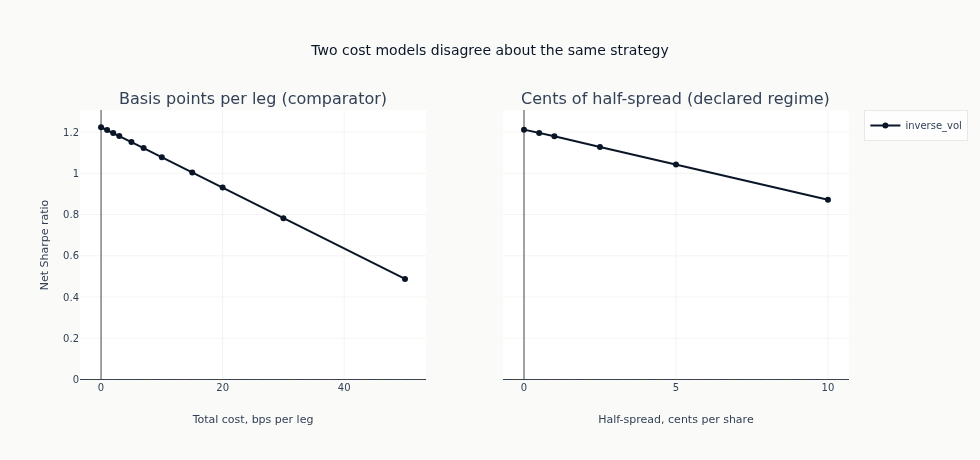

In [13]:
fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=("Basis points per leg (comparator)", "Cents of half-spread (declared regime)"),
)
allocators = sorted(
    set(bps_curve["allocator"].to_list() if not bps_curve.is_empty() else [])
    | set(ps_curve["allocator"].to_list() if not ps_curve.is_empty() else [])
)
palette = ml4t_palette(max(len(allocators), 1), categorical=True)
for column, curve in ((1, bps_curve), (2, ps_curve)):
    if curve.is_empty():
        continue
    for index, allocator in enumerate(allocators):
        subset = curve.filter(pl.col("allocator") == allocator).sort("level")
        if subset.is_empty():
            continue
        fig.add_trace(
            go.Scatter(
                x=subset["level"].to_list(),
                y=subset["sharpe"].to_list(),
                mode="lines+markers",
                name=allocator,
                legendgroup=allocator,
                showlegend=column == 1,
                line=dict(color=palette[index % len(palette)]),
            ),
            row=1,
            col=column,
        )
    fig.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=1, col=column
    )
fig.update_xaxes(title_text="Total cost, bps per leg", row=1, col=1)
fig.update_xaxes(title_text="Half-spread, cents per share", row=1, col=2)
fig.update_yaxes(title_text="Net Sharpe ratio", row=1, col=1)
fig.update_layout(
    title="Two cost models disagree about the same strategy",
    height=460,
    width=980,
    margin=dict(t=110),
)
_all_sharpes = pl.concat(
    [curve["sharpe"] for curve in (bps_curve, ps_curve) if not curve.is_empty()]
)
show_plotly_with_alt(
    fig,
    "Two side-by-side line charts of net Sharpe ratio against transaction cost, one line per "
    "allocator, sharing a y-axis, each with a dashed line at zero. The left panel's x-axis is "
    "basis points per leg and the right panel's is cents of half-spread per share. Counted from "
    f"the frames: {bps_curve.height} points on the left and {ps_curve.height} on the right, across "
    f"{len(allocators)} allocators, net Sharpe from {_all_sharpes.min():+.2f} to "
    f"{_all_sharpes.max():+.2f}.",
)

## 4. What to notice

**The rebalancing cadence is what buys cost tolerance, and it is a design choice rather than a
result.** A position held for a month pays its round trip once and earns a month of return
against it; the same position held for a day pays it about twenty times over the same month. So
where the crossing falls - or whether the grid reaches one at all - was largely decided by the
label horizon back in [`02_labels`](02_labels.ipynb), long before any cost was charged.

**A grid that does not reach the crossing has still answered something.** It bounds the friction
the strategy tolerates from below rather than locating it, and the honest report of that is the
bound, not an extrapolation of the curve past its last point. Widening the grid is what would
locate it, and that is a decision about what friction is worth modelling rather than a defect in
the sweep.

**The two regimes are two different questions, and the declared one is the per-share panel.** A
basis-point cost says friction scales with the value traded. A per-share cost says it scales with
the number of shares, which is what an ETF spread actually does - so the same half-spread is
cheap on a high-priced fund and expensive on a low-priced one, and a universe holding both is
mis-priced by either model applied uniformly. The gap between the panels is the size of that
convention's effect on this universe.

**A breakeven is not a safety margin.** It is where the mean Sharpe reaches zero on a curve
fitted to validation folds, under a uniform cost, with no market impact and no capacity limit.
The distance between the declared cost and that crossing is worth knowing and is not a promise.

**Known limitations.** The sweep applies one flat rate to every fund while the production stages
price each from the tiered map, so this is sensitivity to a level rather than a re-pricing.
Nothing here models impact, so a larger book than the declared initial cash would face costs this
curve does not contain. The combinations re-priced are the leaders of their pool, so the curve
describes how the strategies that already did well degrade, not how the whole population does.
And every point is measured on validation folds; the holdout is not consulted.

**Next**: [`18_holdout_predictions`](18_holdout_predictions.ipynb) refits the carrier this
sweep priced on the history before the holdout window, [`19_holdout_backtest`](19_holdout_backtest.ipynb)
trades it there, and [`20_strategy_analysis`](20_strategy_analysis.ipynb) reports the whole
progression. This is the last stage that selects; nothing after it chooses anything.